(hub-steps)=
# Hub steps

You can import predefined steps from the MLRun hub and use them in your graph. Predefined
steps save you time and effort. Typical usage of predefined steps includes: guardrails (toxicity check, specific subject check),
classifier, translator, PDF parser. You can also save predefined steps to your private hub for reuse.

This icon in the UI indicates hub steps: <img src="../_static/images/steps-hub.png" alt="steps-hub" width="30"/>.

See also [Steps](../runtimes/load-from-hub.md#steps).

First, create the project:

In [ ]:
project = mlrun.get_or_create_project("import-hub-step", context="./")

> 2026-03-25 12:26:39,477 [info] Project loaded successfully: {"project_name":"import-hub-step"}


Create a function that sums two given values:

In [ ]:
%%writefile sum_handler.py
from typing import Any, Dict

def start(event: Dict[str, Any]):
    print("start received:", event)
    return event

def sum_xy(event: Dict[str, Any]):
    x = event["x"]
    y = event["y"]
    return {
        "x": x,
        "y": y,
        "sum": x + y,
    }

Create the MLRun serving function that calls the `sum_handler.py`.

In [4]:
fn = project.set_function(
    name="sum-graph",
    func="sum_handler.py",
    kind="serving",
    image="mlrun/mlrun",
)

In [5]:
graph = fn.set_topology("flow", engine="async")
schema = ["x", "y"]

The `verify_schema` step validates that the event dictionary in `sum_handler.py` contains exactly the keys defined in the schema defined above (`schema = ["x", "y"]`).

In [6]:
graph.add_step(name="start", handler="start").to(
    class_name="hub://verify_schema",
    name="verify",
    schema=schema,
).to(
    name="sum",
    handler="sum_xy",
).respond()

> 2026-03-25 12:26:39,635 [info] Hub URI 'hub://verify_schema' does not specify a version (or uses 'latest'). The step will be pinned to version '1.0.0'.


Plot the graph, and see that the verification is performed before summing the two integers:

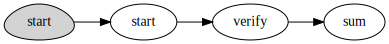

In [7]:
graph.plot(rankdir="LR")

In [8]:
project.deploy_function(fn)

> 2026-03-25 12:26:39,793 [info] Starting remote function deploy
2026-03-25 12:26:40  (info) Deploying function
2026-03-25 12:26:40  (info) Building
2026-03-25 12:26:40  (info) Staging files and preparing base images
2026-03-25 12:26:40  (warn) Using user provided base image, runtime interpreter version is provided by the base image
2026-03-25 12:26:40  (info) Building processor image
2026-03-25 12:27:45  (info) Build complete
2026-03-25 12:27:53  (info) Function deploy complete
> 2026-03-25 12:28:00,774 [info] Model endpoint creation task completed with state succeeded
> 2026-03-25 12:28:00,775 [info] Successfully deployed function: {"external_invocation_urls":["import-hub-step-sum-graph.default-tenant.app.cust-cs-il.iguazio-cd0.com/"],"internal_invocation_urls":["nuclio-import-hub-step-sum-graph.default-tenant.svc.cluster.local:8080"]}


DeployStatus(state=ready, outputs={'endpoint': 'http://import-hub-step-sum-graph.default-tenant.app.cust-cs-il.iguazio-cd0.com/', 'name': 'import-hub-step-sum-graph'})

And, finally, call the function, giving the variables values. The function prints the numbers in the schema and their sum:

In [9]:
serving_fn = project.get_function("sum-graph")
result = serving_fn.invoke("/", body={"x": 7, "y": 8})
print(result)

{'x': 7, 'y': 8, 'sum': 15}
